### **Quantum-Assisted PINN (QA-PINN) for 1D Burgers — with full XAI**

1. **Circuit depth & parameter count** vs qubit number
2. **Fourier frequency spectrum** of the quantum feature map (Schuld-Sweke-Meyer)
3. **Entanglement capability** (Meyer-Wallach / Q-measure) before vs after training
4. **Effective feature rank** of the $2^n$-dim readout (decoder-bottleneck diagnostic)
5. **Loss-landscape roughness** around the trained minimum


In [1]:
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt

import burgers_common as bc

torch.manual_seed(0)
np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {DEVICE}") 
print("pennylane", qml.__version__, "| torch", torch.__version__)
print(f"nu = {bc.NU:.6f}")

Running on cuda
pennylane 0.45.1 | torch 2.6.0+cu124
nu = 0.003183


In [2]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True   # RTX 3050 Ampere: free speedup

In [3]:
def make_quantum_layer(n_qubits, n_layers=8, reupload=False):
    # torch-native device keeps the statevector on GPU; no host round-trip
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        # inputs: (batch, 2) -> broadcast over batch dim automatically.
        # Encode BOTH x and t across all qubits (tile to n_qubits).
        qml.AngleEmbedding(inputs, wires=range(inputs.shape[-1]), rotation="X")
        for l in range(n_layers):
            if reupload and l > 0:
                qml.AngleEmbedding(inputs, wires=range(inputs.shape[-1]), rotation="X")
            for w in range(n_qubits):
                qml.RX(weights[l, w], wires=w)
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qml.CNOT(wires=[i, j])
        return qml.probs(wires=range(n_qubits))
    return circuit

In [7]:
class QAPINN(nn.Module):
    def __init__(self, n_qubits, hidden=8, n_layers=8, reupload=False):
        super().__init__()
        self.n_qubits = n_qubits
        self.qnode = make_quantum_layer(n_qubits, n_layers, reupload=reupload)
        self.q_weights = nn.Parameter(torch.empty(n_layers, n_qubits))
        nn.init.uniform_(self.q_weights, -np.pi, np.pi)
        self.head = nn.Sequential(
            nn.Linear(2 ** n_qubits, hidden), nn.Tanh(), nn.Linear(hidden, 1))

    def forward(self, X):
        dev = X.device
        q_out = self.qnode(X.cpu(), self.q_weights.cpu())   # (batch, 2^n) on CPU
        return self.head(q_out.to(dev, dtype=X.dtype))

    def quantum_features(self, X):
        with torch.no_grad():
            return self.qnode(X.cpu(), self.q_weights.cpu()).to(X.device, dtype=X.dtype)


for n in (3, 4, 5):
    m = QAPINN(n)
    p = sum(x.numel() for x in m.parameters() if x.requires_grad)
    q = 8 * n
    print(f"{n} qubits: total params = {p:4d}  (quantum RX = {q}, head = {p - q})")

3 qubits: total params =  105  (quantum RX = 24, head = 81)
4 qubits: total params =  177  (quantum RX = 32, head = 145)
5 qubits: total params =  313  (quantum RX = 40, head = 273)


In [8]:
# ---- Cache collocation points ONCE (huge speedup over resampling each step) ----
def build_batches(n_pde=1000, n_ic=256, n_bc=100):
    x_f, t_f = bc.sample_interior(n_pde, DEVICE)
    x0, t0, u0 = bc.sample_ic(n_ic, DEVICE)
    xb_pos, xb_neg, tb = bc.sample_bc(n_bc, DEVICE)
    return (x_f, t_f, x0, t0, u0, xb_pos, xb_neg, tb)

def composite_loss(model, batches):
    x_f, t_f, x0, t0, u0, xb_pos, xb_neg, tb = batches
    loss_pde = (bc.pde_residual(model, x_f, t_f) ** 2).mean()
    loss_ic  = ((model(torch.cat([x0, t0], 1)) - u0) ** 2).mean()
    loss_bc  = ((model(torch.cat([xb_pos, tb], 1)) ** 2).mean()
                + (model(torch.cat([xb_neg, tb], 1)) ** 2).mean())
    return loss_pde + loss_ic + loss_bc, \
        {"pde": loss_pde.item(), "ic": loss_ic.item(), "bc": loss_bc.item()}

def train_qapinn(n_qubits, epochs=400, lr=1e-3, hidden=8, reupload=False,
                 log_every=50, resample_every=0):
    model = QAPINN(n_qubits, hidden=hidden, reupload=reupload).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    batches = build_batches()
    hist = []
    model.train()
    for ep in range(epochs):
        if resample_every and ep and ep % resample_every == 0:
            batches = build_batches()          # optional fresh collocation
        opt.zero_grad(set_to_none=True)         # cheaper than zero_grad()
        loss, parts = composite_loss(model, batches)
        loss.backward()
        opt.step()
        hist.append(loss.item())
        if ep % log_every == 0 or ep == epochs - 1:
            print(f"  [{n_qubits}q] ep {ep:4d} | loss {loss.item():.4e} | "
                  f"pde {parts['pde']:.2e} ic {parts['ic']:.2e} bc {parts['bc']:.2e}")
    return model, hist

/dolfinx-env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [3q] ep    0 | loss 5.4087e-01 | pde 1.73e-03 ic 5.19e-01 bc 2.06e-02
  [3q] ep  100 | loss 4.6219e-01 | pde 1.62e-02 ic 4.44e-01 bc 2.35e-03
  [3q] ep  200 | loss 4.3592e-01 | pde 4.27e-02 ic 3.84e-01 bc 8.98e-03
  [3q] ep  300 | loss 4.3387e-01 | pde 4.50e-02 ic 3.80e-01 bc 9.19e-03
  [3q] ep  400 | loss 4.3305e-01 | pde 4.54e-02 ic 3.78e-01 bc 9.35e-03
  [3q] ep  500 | loss 4.3269e-01 | pde 4.55e-02 ic 3.78e-01 bc 9.57e-03
  [3q] ep  600 | loss 4.3241e-01 | pde 4.55e-02 ic 3.77e-01 bc 9.72e-03
  [3q] ep  700 | loss 4.3207e-01 | pde 4.56e-02 ic 3.77e-01 bc 9.80e-03
  [3q] ep  800 | loss 4.3163e-01 | pde 4.57e-02 ic 3.76e-01 bc 9.87e-03
  [3q] ep  900 | loss 4.3101e-01 | pde 4.58e-02 ic 3.75e-01 bc 9.93e-03
  [3q] ep 1000 | loss 4.3008e-01 | pde 4.61e-02 ic 3.74e-01 bc 1.00e-02
  [3q] ep 1100 | loss 4.2861e-01 | pde 4.64e-02 ic 3.72e-01 bc 1.01e-02
  [3q] ep 1200 | loss 4.2625e-01 | pde 4.70e-02 ic 3.69e-01 bc 1.01e-02
  [3q] ep 1300 | loss 4.2246e-01 | pde 4.76e-02 ic 3.65e-01 bc 1

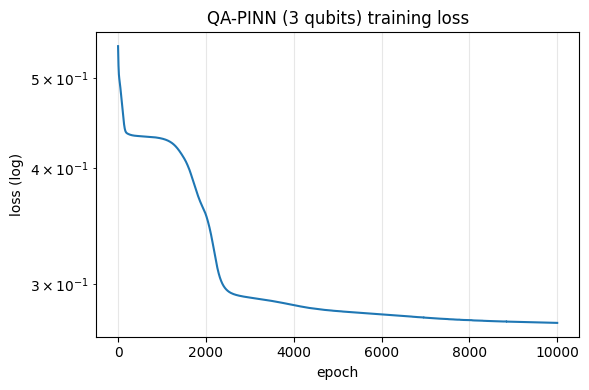

In [9]:
model_3q, hist_3q = train_qapinn(3, epochs=10000, reupload=True, log_every=100)

plt.figure(figsize=(6, 4))
plt.semilogy(hist_3q)
plt.xlabel("epoch"); plt.ylabel("loss (log)")
plt.title("QA-PINN (3 qubits) training loss"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
import os, json
from datetime import datetime
CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

def save_run(model, hist, n_qubits, *, tag="qapinn", fig=None,
             extra_meta=None, ckpt_dir=CKPT_DIR):
    """Save model weights, loss history, figure, and metadata for one run."""
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base  = f"{tag}_{n_qubits}q_{stamp}"
    paths = {}

    # 1) model weights (+ enough to reconstruct the module)
    ckpt = {
        "state_dict":  model.state_dict(),
        "n_qubits":    n_qubits,
        "n_layers":    getattr(model, "n_layers", None),
        "hidden":      model.head[0].out_features,  # infer head width
        "reupload":    True,
    }
    paths["model"] = os.path.join(ckpt_dir, base + ".pt")
    torch.save(ckpt, paths["model"])

    # 2) loss history as .npy (fast) — hist here is a list of totals
    paths["hist"] = os.path.join(ckpt_dir, base + "_hist.npy")
    np.save(paths["hist"], np.asarray(hist, dtype=np.float32))

    # 3) figure (save the current fig if none passed)
    paths["fig"] = os.path.join(ckpt_dir, base + "_loss.png")
    (fig or plt.gcf()).savefig(paths["fig"], dpi=150, bbox_inches="tight")

    # 4) metadata / provenance
    meta = {
        "tag": tag, "n_qubits": n_qubits, "timestamp": stamp,
        "final_loss": float(hist[-1]), "epochs": len(hist),
        "seed": 0, "device": str(DEVICE),
        "pennylane": qml.__version__, "torch": torch.__version__,
        "nu": float(bc.NU),
    }
    if extra_meta:
        meta.update(extra_meta)
    paths["meta"] = os.path.join(ckpt_dir, base + "_meta.json")
    with open(paths["meta"], "w") as fh:
        json.dump(meta, fh, indent=2)

    print(f"saved run '{base}':")
    for k, v in paths.items():
        print(f"  {k:6s} -> {v}")
    return paths


def load_run(model_path, model_cls=QAPINN, device=None):
    """Rebuild a QAPINN and load weights from a saved .pt checkpoint."""
    device = device or DEVICE
    ckpt = torch.load(model_path, map_location=device)
    model = model_cls(ckpt["n_qubits"],
                      hidden=ckpt["hidden"],
                      reupload=ckpt.get("reupload", True)).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model, ckpt

In [12]:
save_run(model_3q, hist_3q, n_qubits=3, tag="qapinn_burgers")

saved run 'qapinn_burgers_3q_20260715_065943':
  model  -> checkpoints/qapinn_burgers_3q_20260715_065943.pt
  hist   -> checkpoints/qapinn_burgers_3q_20260715_065943_hist.npy
  fig    -> checkpoints/qapinn_burgers_3q_20260715_065943_loss.png
  meta   -> checkpoints/qapinn_burgers_3q_20260715_065943_meta.json


{'model': 'checkpoints/qapinn_burgers_3q_20260715_065943.pt',
 'hist': 'checkpoints/qapinn_burgers_3q_20260715_065943_hist.npy',
 'fig': 'checkpoints/qapinn_burgers_3q_20260715_065943_loss.png',
 'meta': 'checkpoints/qapinn_burgers_3q_20260715_065943_meta.json'}

<Figure size 640x480 with 0 Axes>

=== training 3-qubit QA-PINN ===
  [3q] ep    0 | loss 5.2798e-01 | pde 3.99e-04 ic 5.04e-01 bc 2.32e-02
  [3q] ep   50 | loss 4.8345e-01 | pde 3.09e-04 ic 4.83e-01 bc 3.42e-04
  [3q] ep  100 | loss 4.5781e-01 | pde 5.15e-04 ic 4.54e-01 bc 2.87e-03
  [3q] ep  150 | loss 4.2609e-01 | pde 5.24e-03 ic 4.05e-01 bc 1.55e-02
  [3q] ep  200 | loss 4.0895e-01 | pde 1.34e-02 ic 3.68e-01 bc 2.76e-02
  [3q] ep  250 | loss 4.0554e-01 | pde 2.09e-02 ic 3.53e-01 bc 3.14e-02
  [3q] ep  300 | loss 4.0433e-01 | pde 2.25e-02 ic 3.50e-01 bc 3.21e-02
  [3q] ep  350 | loss 4.0318e-01 | pde 2.25e-02 ic 3.48e-01 bc 3.22e-02
  [3q] ep  400 | loss 4.0199e-01 | pde 2.24e-02 ic 3.47e-01 bc 3.23e-02
  [3q] ep  450 | loss 4.0079e-01 | pde 2.22e-02 ic 3.46e-01 bc 3.23e-02
  [3q] ep  500 | loss 3.9962e-01 | pde 2.22e-02 ic 3.45e-01 bc 3.23e-02
  [3q] ep  550 | loss 3.9852e-01 | pde 2.25e-02 ic 3.44e-01 bc 3.24e-02
  [3q] ep  600 | loss 3.9747e-01 | pde 2.28e-02 ic 3.42e-01 bc 3.24e-02
  [3q] ep  650 | loss 3.9644e-0

/workspaces/PINN/notebooks/burgers_common.py:22: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  num, _ = integrate.quad(_num, -np.inf, np.inf, limit=200)


  -> mean relative L2 = 5.1171e-01
saved run 'qapinn_sweep_3q_20260715_072526':
  model  -> checkpoints/qapinn_sweep_3q_20260715_072526.pt
  hist   -> checkpoints/qapinn_sweep_3q_20260715_072526_hist.npy
  fig    -> checkpoints/qapinn_sweep_3q_20260715_072526_loss.png
  meta   -> checkpoints/qapinn_sweep_3q_20260715_072526_meta.json


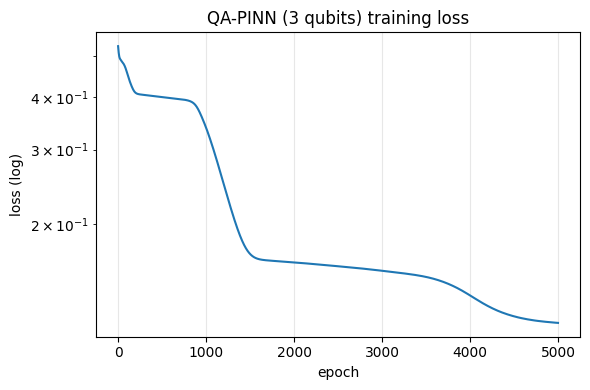

=== training 4-qubit QA-PINN ===
  [4q] ep    0 | loss 5.1076e-01 | pde 4.25e-05 ic 5.03e-01 bc 7.39e-03
  [4q] ep   50 | loss 4.7196e-01 | pde 4.11e-05 ic 4.67e-01 bc 4.59e-03
  [4q] ep  100 | loss 4.4833e-01 | pde 3.31e-04 ic 4.27e-01 bc 2.14e-02
  [4q] ep  150 | loss 4.2729e-01 | pde 2.81e-03 ic 3.93e-01 bc 3.13e-02
  [4q] ep  200 | loss 4.0678e-01 | pde 1.35e-02 ic 3.59e-01 bc 3.38e-02
  [4q] ep  250 | loss 4.0132e-01 | pde 2.52e-02 ic 3.42e-01 bc 3.40e-02
  [4q] ep  300 | loss 4.0037e-01 | pde 2.77e-02 ic 3.38e-01 bc 3.43e-02
  [4q] ep  350 | loss 3.9956e-01 | pde 2.78e-02 ic 3.37e-01 bc 3.43e-02
  [4q] ep  400 | loss 3.9873e-01 | pde 2.78e-02 ic 3.37e-01 bc 3.43e-02
  [4q] ep  450 | loss 3.9788e-01 | pde 2.79e-02 ic 3.36e-01 bc 3.42e-02
  [4q] ep  500 | loss 3.9702e-01 | pde 2.80e-02 ic 3.35e-01 bc 3.41e-02
  [4q] ep  550 | loss 3.9617e-01 | pde 2.81e-02 ic 3.34e-01 bc 3.39e-02
  [4q] ep  600 | loss 3.9534e-01 | pde 2.84e-02 ic 3.33e-01 bc 3.38e-02
  [4q] ep  650 | loss 3.9453e-0

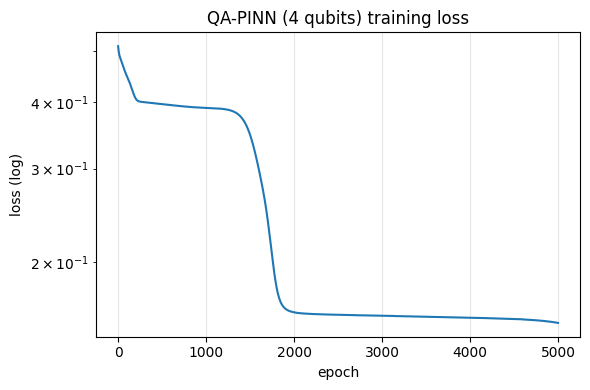

=== training 5-qubit QA-PINN ===
  [5q] ep    0 | loss 4.9536e-01 | pde 3.59e-06 ic 4.77e-01 bc 1.81e-02
  [5q] ep   50 | loss 4.4514e-01 | pde 7.52e-05 ic 4.43e-01 bc 2.10e-03
  [5q] ep  100 | loss 4.1922e-01 | pde 1.01e-03 ic 4.07e-01 bc 1.16e-02
  [5q] ep  150 | loss 4.0135e-01 | pde 5.69e-03 ic 3.72e-01 bc 2.39e-02
  [5q] ep  200 | loss 3.9494e-01 | pde 1.30e-02 ic 3.52e-01 bc 2.95e-02
  [5q] ep  250 | loss 3.9328e-01 | pde 1.66e-02 ic 3.45e-01 bc 3.14e-02
  [5q] ep  300 | loss 3.9208e-01 | pde 1.69e-02 ic 3.43e-01 bc 3.17e-02
  [5q] ep  350 | loss 3.9083e-01 | pde 1.68e-02 ic 3.42e-01 bc 3.19e-02
  [5q] ep  400 | loss 3.8951e-01 | pde 1.67e-02 ic 3.41e-01 bc 3.21e-02
  [5q] ep  450 | loss 3.8820e-01 | pde 1.69e-02 ic 3.39e-01 bc 3.23e-02
  [5q] ep  500 | loss 3.8695e-01 | pde 1.73e-02 ic 3.37e-01 bc 3.24e-02
  [5q] ep  550 | loss 3.8583e-01 | pde 1.79e-02 ic 3.35e-01 bc 3.25e-02
  [5q] ep  600 | loss 3.8484e-01 | pde 1.86e-02 ic 3.34e-01 bc 3.25e-02
  [5q] ep  650 | loss 3.8400e-0

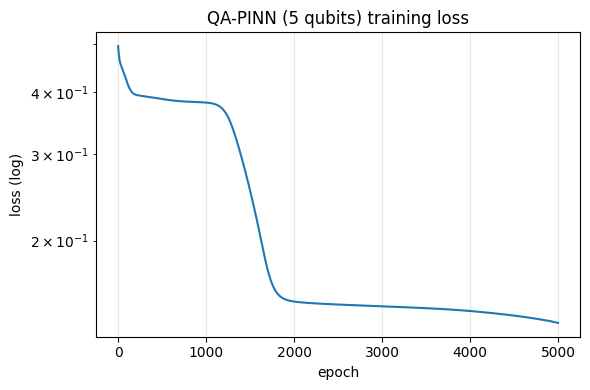

In [13]:
EPOCHS_SWEEP = 5000
T_SNAPSHOTS = [0.25, 0.50, 0.75, 0.99]

sweep = {}
for n in (3, 4, 5):
    print(f"=== training {n}-qubit QA-PINN ===")
    model, hist = train_qapinn(n, epochs=EPOCHS_SWEEP)
    res = bc.evaluate_on_grid(model, T_SNAPSHOTS, nx=256, device=DEVICE)
    mean_l2 = float(np.mean([v[3] for v in res.values()]))
    sweep[n] = {"model": model, "history": hist, "results": res, "mean_l2": mean_l2}
    print(f"  -> mean relative L2 = {mean_l2:.4e}")

    fig = plt.figure(figsize=(6, 4))
    plt.semilogy(hist)
    plt.xlabel("epoch"); plt.ylabel("loss (log)")
    plt.title(f"QA-PINN ({n} qubits) training loss")
    plt.grid(True, alpha=0.3); plt.tight_layout()

    save_run(model, hist, n_qubits=n, tag="qapinn_sweep",
             fig=fig, extra_meta={"mean_rel_l2": mean_l2,
                                  "t_snapshots": T_SNAPSHOTS})
    plt.show()

In [14]:
# Summary table
print(f"{'qubits':>7} | {'params':>7} | {'mean rel-L2':>12}")
for n in (3, 4, 5):
    p = sum(x.numel() for x in sweep[n]['model'].parameters() if x.requires_grad)
    print(f"{n:>7} | {p:>7} | {sweep[n]['mean_l2']:>12.4e}")

 qubits |  params |  mean rel-L2
      3 |     105 |   5.1171e-01
      4 |     177 |   6.0576e-01
      5 |     313 |   5.8835e-01


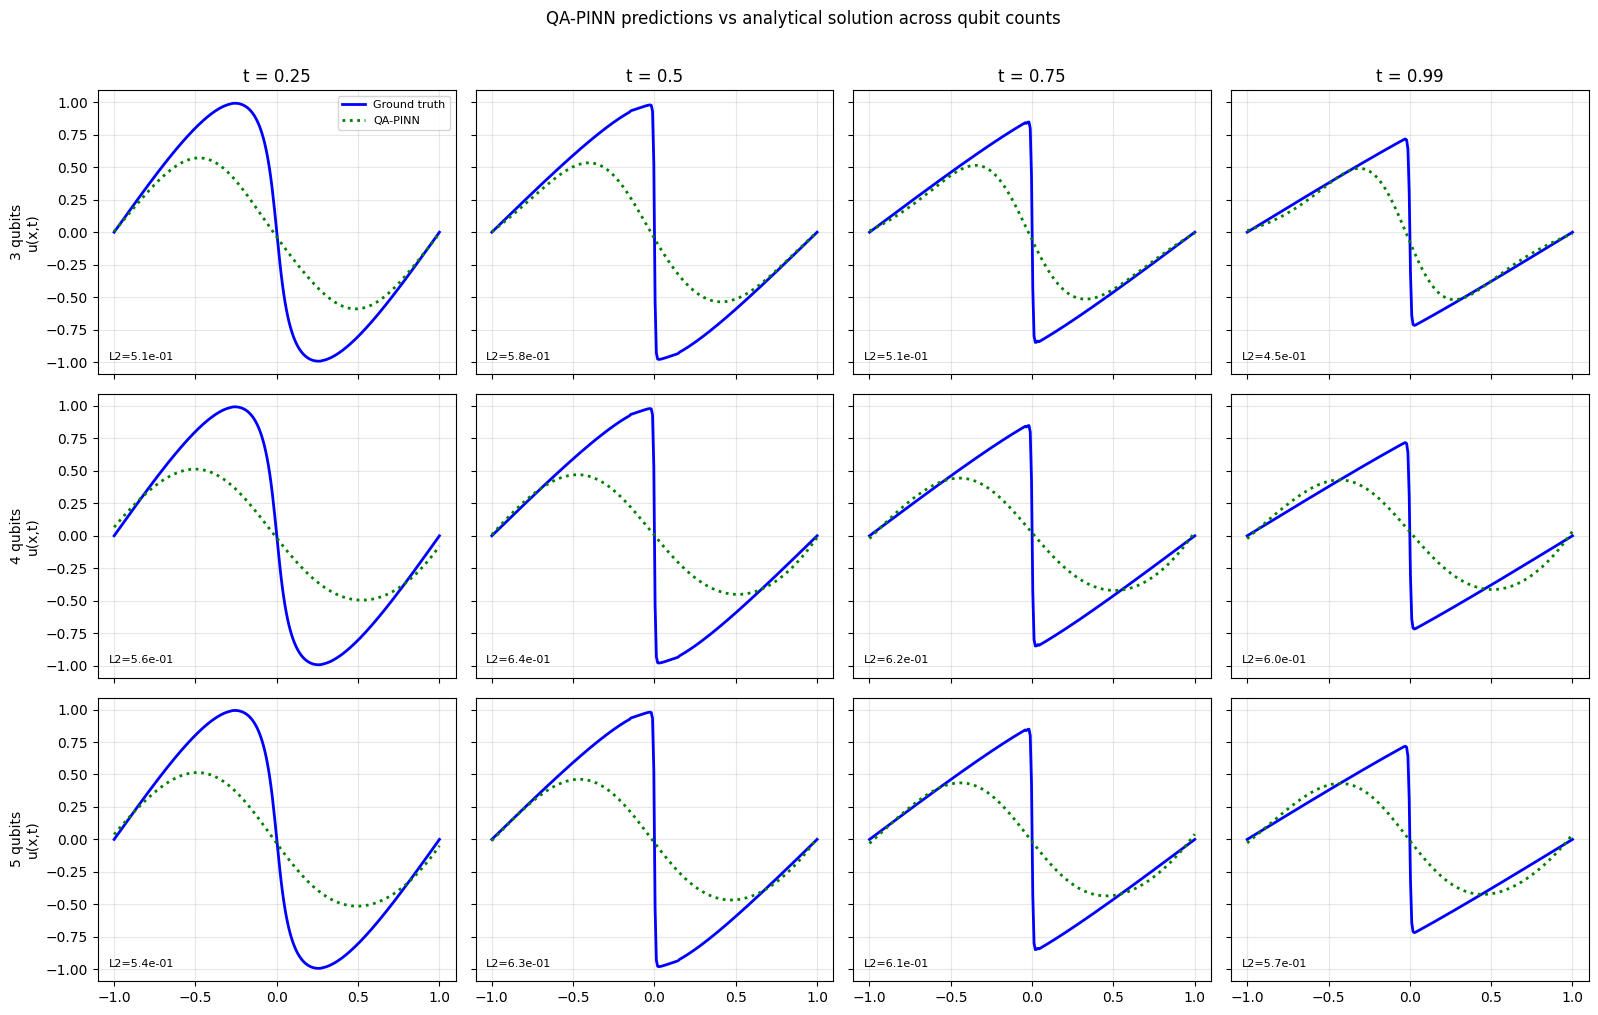

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for row, n in enumerate((3, 4, 5)):
    for col, t in enumerate(T_SNAPSHOTS):
        ax = axes[row, col]
        x_grid, u_pred, u_exact, l2 = sweep[n]['results'][t]
        ax.plot(x_grid, u_exact, 'b-', lw=2, label='Ground truth')
        ax.plot(x_grid, u_pred, 'g:', lw=2, label='QA-PINN')
        if row == 0:
            ax.set_title(f"t = {t}")
        if col == 0:
            ax.set_ylabel(f"{n} qubits\nu(x,t)")
        ax.text(0.03, 0.05, f"L2={l2:.1e}", transform=ax.transAxes, fontsize=8)
        ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle("QA-PINN predictions vs analytical solution across qubit counts", y=1.01)
plt.tight_layout(); plt.show()

## **Analysis using XAI Techniques**

### 1. **Circuit depth & parameter scaling**

Full entanglement means each layer has $\binom{n}{2}$ CNOTs, so **two-qubit depth grows
quadratically** in $n$ while the trainable rotations grow only linearly ($8n$). This is the
capacity/trainability tension: more qubits buy exponential ambient dimension ($2^n$) but at
rising entangling depth.

In [16]:
def circuit_stats(n_qubits, n_layers=8):
    rx = n_layers * n_qubits                        # trainable single-qubit rotations
    cnots = n_layers * (n_qubits * (n_qubits - 1) // 2)  # full-entanglement CNOTs
    # specs via PennyLane
    model = QAPINN(n_qubits)
    specs = qml.specs(model.qnode)(torch.tensor([0.3, 0.5]),
                                   torch.zeros(n_layers, n_qubits))
    depth = specs['resources'].depth
    return rx, cnots, depth

print(f"{'qubits':>7} | {'RX (train)':>11} | {'CNOTs':>6} | {'2^n dim':>8} | {'depth':>6}")
for n in (3, 4, 5):
    rx, cnots, depth = circuit_stats(n)
    print(f"{n:>7} | {rx:>11} | {cnots:>6} | {2**n:>8} | {depth:>6}")

 qubits |  RX (train) |  CNOTs |  2^n dim |  depth
      3 |          24 |     24 |        8 |     33
      4 |          32 |     48 |       16 |     42
      5 |          40 |     80 |       32 |     51


### **2. Fourier frequency spectrum of the feature map**

Schuld, Sweke & Meyer (Phys. Rev. A 2021) show a variational quantum model is a **Fourier
series** in its inputs, whose accessible frequencies are fixed by the **data-encoding gates**.
A single $R_X(x)$ per input gives eigenvalues $\{-\tfrac12,+\tfrac12\}$, i.e. accessible
frequencies $\{-1,0,+1\}$ per input. A Burgers **shock** is spectrally broad — so this thin
spectrum is a prime suspect for the poor shock resolution.

Below we empirically recover the spectrum by sampling one quantum-feature output over $x$ (at
fixed $t$) and taking its FFT, with **encoding = single** vs **data re-uploading**.

In [20]:
CKPT_DIR = os.path.join("checkpoints")   # notebooks/checkpoints when run from notebooks/
os.makedirs(CKPT_DIR, exist_ok=True)

def savefig(fig, name, dpi=150):
    """Save every XAI figure into notebooks/checkpoints/."""
    path = os.path.join(CKPT_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved -> {path}")
    return path

QUBIT_COLORS = {3: "#4C72B0", 4: "#55A868", 5: "#C44E52"}

single RX encoding      support edge =  26.9 cyc | centroid =  3.57
data re-uploading       support edge =  15.0 cyc | centroid =  2.02
saved -> checkpoints/xai_fourier_spectrum_corrected.png


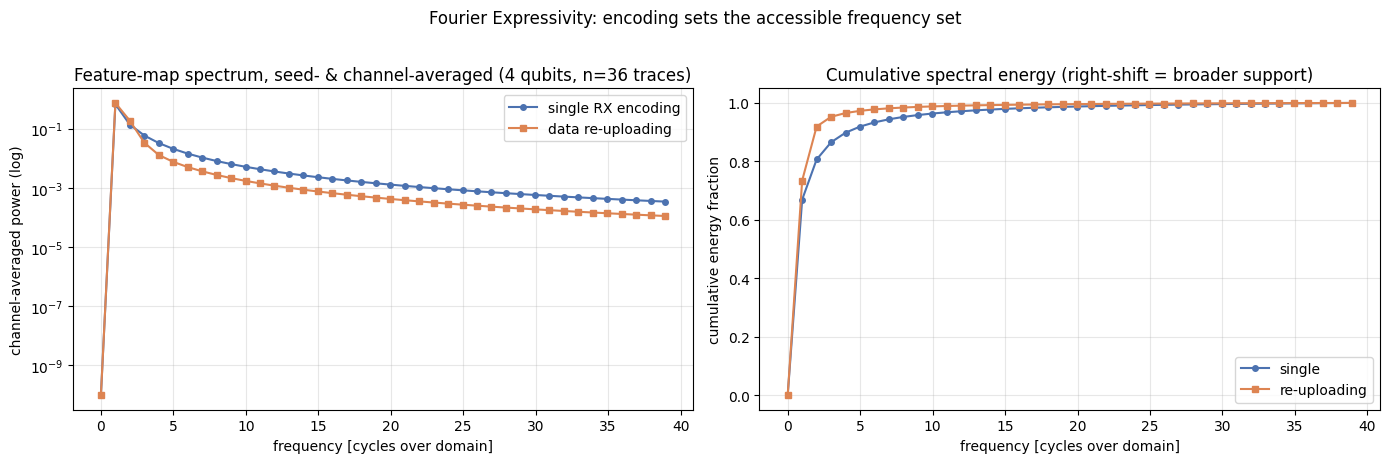

In [21]:
# XAI-2. Fourier spectrum: single-encoding vs re-uploading
#   - identical weights for both circuits (only encoding differs)
#   - averaged over channels AND random seeds (probes the function CLASS)
#   - reports accessible-frequency SUPPORT, not just a centroid

def _feature_spectrum_avg(circuit_fn, n_qubits, n_layers, weights,
                          n_samples=512, t_fixed=0.5):
    """FFT of every 2^n feature channel over x, averaged into one spectrum."""
    xs = np.linspace(-1.0, 1.0, n_samples)
    X = torch.tensor(np.stack([xs, np.full_like(xs, t_fixed)], 1), dtype=torch.float32)
    with torch.no_grad():
        feats = circuit_fn(X, weights).cpu().numpy()          # (n_samples, 2^n)
    dx = (xs[1] - xs[0]) / 2.0                                 # map [-1,1] span = 2
    freqs = np.fft.rfftfreq(n_samples, d=dx)
    acc = np.zeros_like(freqs)
    for c in range(feats.shape[1]):
        sig = feats[:, c] - feats[:, c].mean()
        p = np.abs(np.fft.rfft(sig)) ** 2
        acc += p
    acc /= feats.shape[1]
    acc /= (acc.sum() + 1e-30)                                 # normalise to unit energy
    return freqs, acc

def _support_edge(freqs, power, floor=1e-3):
    """Highest frequency whose (normalised) power exceeds a noise floor."""
    mask = power > floor * power.max()
    return float(freqs[mask].max()) if mask.any() else 0.0

def _centroid(freqs, power):
    return float((freqs * power).sum() / (power.sum() + 1e-30))

def compare_encoding_spectra(n_qubits=4, n_layers=8, n_seeds=12,
                             n_samples=512, t_slices=(0.25, 0.5, 0.75)):
    circ_single = make_quantum_layer(n_qubits, n_layers, reupload=False)
    circ_reup   = make_quantum_layer(n_qubits, n_layers, reupload=True)

    single_spec, reup_spec, freqs = [], [], None
    for seed in range(n_seeds):
        g = torch.Generator().manual_seed(seed)
        # SAME weights handed to BOTH circuits -> only the encoding differs
        w = torch.empty(n_layers, n_qubits).uniform_(-np.pi, np.pi, generator=g)
        for t in t_slices:
            f, ps = _feature_spectrum_avg(circ_single, n_qubits, n_layers, w, n_samples, t)
            _, pr = _feature_spectrum_avg(circ_reup,   n_qubits, n_layers, w, n_samples, t)
            freqs = f
            single_spec.append(ps); reup_spec.append(pr)

    single = np.mean(single_spec, axis=0)
    reup   = np.mean(reup_spec,   axis=0)
    return freqs, single, reup

freqs, single, reup = compare_encoding_spectra(n_qubits=4)

# ---- report support edges + centroids -------------------------------
for name, spec in [("single RX encoding", single), ("data re-uploading", reup)]:
    print(f"{name:22s}  support edge = {_support_edge(freqs, spec):5.1f} cyc | "
          f"centroid = {_centroid(freqs, spec):5.2f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5))
kmax = 40
axL.semilogy(freqs[:kmax], single[:kmax] + 1e-10, "o-", color="#4C72B0",
             label="single RX encoding", ms=4)
axL.semilogy(freqs[:kmax], reup[:kmax] + 1e-10, "s-", color="#DD8452",
             label="data re-uploading", ms=4)
axL.set_xlabel("frequency [cycles over domain]")
axL.set_ylabel("channel-averaged power (log)")
axL.set_title(f"Feature-map spectrum, seed- & channel-averaged (4 qubits, n={12*3} traces)")
axL.legend(); axL.grid(True, alpha=0.3)

# cumulative-energy view makes the SUPPORT difference obvious
axR.plot(freqs[:kmax], np.cumsum(single[:kmax]) / single[:kmax].sum(),
         "o-", color="#4C72B0", label="single", ms=4)
axR.plot(freqs[:kmax], np.cumsum(reup[:kmax]) / reup[:kmax].sum(),
         "s-", color="#DD8452", label="re-uploading", ms=4)
axR.set_xlabel("frequency [cycles over domain]")
axR.set_ylabel("cumulative energy fraction")
axR.set_title("Cumulative spectral energy (right-shift = broader support)")
axR.legend(); axR.grid(True, alpha=0.3)

fig.suptitle("Fourier Expressivity: encoding sets the accessible frequency set", y=1.02)
plt.tight_layout()
savefig(fig, "xai_fourier_spectrum_corrected.png")
plt.show()

### **3. Entanglement capability (Meyer-Wallach $Q$)**

3 qubits: mean Q = 0.000 ± 0.000  (max 0.000)
4 qubits: mean Q = 0.801 ± 0.000  (max 0.801)
5 qubits: mean Q = 0.881 ± 0.000  (max 0.881)
saved -> checkpoints/xai_entanglement_capability.png


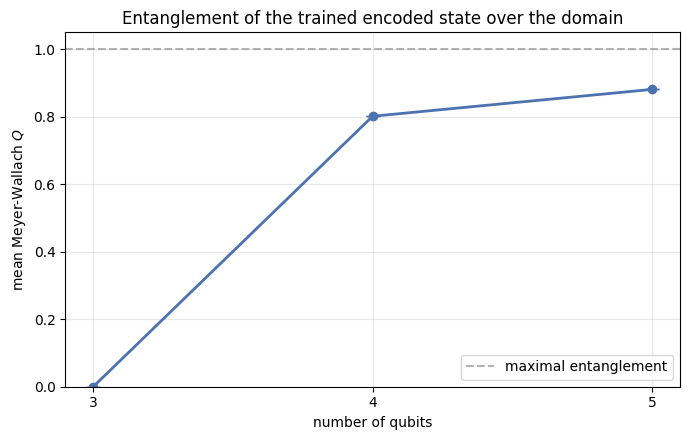

In [22]:
def _state_qnode(n_qubits, n_layers=8, reupload=False):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch")
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(inputs.shape[-1]), rotation="X")
        for l in range(n_layers):
            if reupload and l > 0:
                qml.AngleEmbedding(inputs, wires=range(inputs.shape[-1]), rotation="X")
            for w in range(n_qubits):
                qml.RX(weights[l, w], wires=w)
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qml.CNOT(wires=[i, j])
        return qml.state()
    return circuit

def meyer_wallach(state, n_qubits):
    """Q = 2(1 - (1/n) sum_k Tr rho_k^2) for a pure state vector."""
    psi = np.asarray(state).reshape([2] * n_qubits)
    purities = []
    for k in range(n_qubits):
        axes = tuple(i for i in range(n_qubits) if i != k)
        rho_k = np.tensordot(psi, np.conj(psi), axes=(axes, axes))
        purities.append(np.real(np.trace(rho_k @ rho_k)))
    return float(2.0 * (1.0 - np.mean(purities)))

def entanglement_over_domain(model, n_qubits, n_samples=256, seed=0):
    rng = np.random.default_rng(seed)
    xs = rng.uniform(-1, 1, n_samples)
    ts = rng.uniform(-1, 1, n_samples)
    X = torch.tensor(np.stack([xs, ts], 1), dtype=torch.float32)
    sq = _state_qnode(n_qubits, getattr(model, "n_layers", 8),
                      reupload=getattr(model, "reupload", False))
    w = model.q_weights.detach().cpu()
    Qs = []
    for row in X:
        st = sq(row.unsqueeze(0), w)
        Qs.append(meyer_wallach(st.detach().numpy().reshape(-1), n_qubits))
    return np.array(Qs)

means, stds, qs = [], [], (3, 4, 5)
for n in qs:
    Q = entanglement_over_domain(sweep[n]["model"], n)
    means.append(Q.mean()); stds.append(Q.std())
    print(f"{n} qubits: mean Q = {Q.mean():.3f} ± {Q.std():.3f}  (max {Q.max():.3f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(qs, means, yerr=stds, marker="o", lw=2, capsize=5, color="#4C72B0")
ax.axhline(1.0, ls="--", color="grey", alpha=0.6, label="maximal entanglement")
ax.set_xlabel("number of qubits"); ax.set_ylabel("mean Meyer-Wallach $Q$")
ax.set_xticks(qs); ax.set_ylim(0, 1.05)
ax.set_title("Entanglement of the trained encoded state over the domain")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig(fig, "xai_entanglement_capability.png")
plt.show()

### 4. **Circuit depth analysis**

 qubits |   RX |  CNOTs |   2^n |  depth
      3 |   24 |     24 |     8 |     33
      4 |   32 |     48 |    16 |     42
      5 |   40 |     80 |    32 |     51
saved -> checkpoints/xai_circuit_cost.png


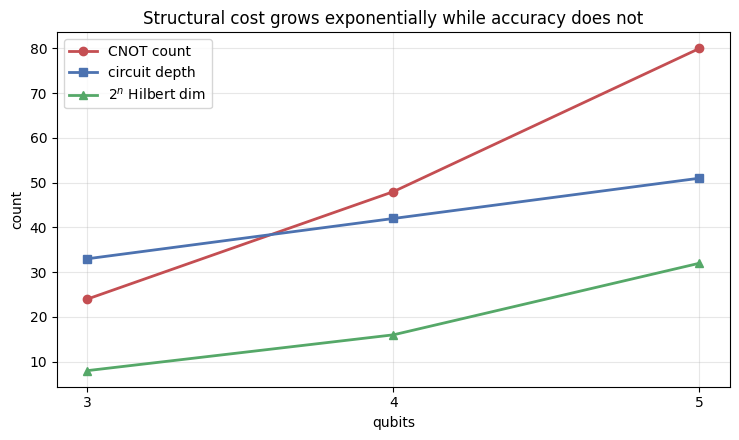

In [23]:
def circuit_stats(n_qubits, n_layers=8):
    rx = n_layers * n_qubits
    cnots = n_layers * (n_qubits * (n_qubits - 1) // 2)   # full entanglement
    model = QAPINN(n_qubits)
    specs = qml.specs(model.qnode)(torch.tensor([0.3, 0.5]),
                                   torch.zeros(n_layers, n_qubits))
    return rx, cnots, specs["resources"].depth

rows = []
print(f"{'qubits':>7} | {'RX':>4} | {'CNOTs':>6} | {'2^n':>5} | {'depth':>6}")
for n in (3, 4, 5):
    rx, cn, d = circuit_stats(n)
    rows.append((n, rx, cn, 2**n, d))
    print(f"{n:>7} | {rx:>4} | {cn:>6} | {2**n:>5} | {d:>6}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ns = [r[0] for r in rows]
ax.plot(ns, [r[2] for r in rows], "o-", label="CNOT count", color="#C44E52", lw=2)
ax.plot(ns, [r[4] for r in rows], "s-", label="circuit depth", color="#4C72B0", lw=2)
ax.plot(ns, [r[3] for r in rows], "^-", label="$2^n$ Hilbert dim", color="#55A868", lw=2)
ax.set_xlabel("qubits"); ax.set_ylabel("count"); ax.set_xticks(ns)
ax.set_title("Structural cost grows exponentially while accuracy does not")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig(fig, "xai_circuit_cost.png")
plt.show()

### 5. **Depth and reuploading hyperparameter sweep**

In [24]:
HP_EPOCHS = 3000
N_Q = 4
layer_grid   = [4, 8, 12]
reup_grid    = [False, True]
import itertools


hp_results = {}
for n_layers, reup in itertools.product(layer_grid, reup_grid):
    # train_qapinn hard-codes n_layers=8 in the current QAPINN; pass via closure:
    def _make(nq): return QAPINN(nq, hidden=8, n_layers=n_layers, reupload=reup).to(DEVICE)
    model = _make(N_Q)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    batches = build_batches()
    for ep in range(HP_EPOCHS):
        opt.zero_grad(set_to_none=True)
        loss, _ = composite_loss(model, batches)
        loss.backward(); opt.step()
    res = bc.evaluate_on_grid(model, T_SNAPSHOTS, nx=256, device=DEVICE)
    mean_l2 = float(np.mean([v[3] for v in res.values()]))
    hp_results[(n_layers, reup)] = mean_l2
    print(f"layers={n_layers:2d} reupload={str(reup):5s} -> mean L2 = {mean_l2:.3e}")

# heatmap
fig, ax = plt.subplots(figsize=(6.5, 4.5))
M = np.array([[hp_results[(l, r)] for r in reup_grid] for l in layer_grid])
im = ax.imshow(M, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(len(reup_grid))); ax.set_xticklabels(["single", "re-upload"])
ax.set_yticks(range(len(layer_grid))); ax.set_yticklabels(layer_grid)
ax.set_xlabel("encoding"); ax.set_ylabel("variational layers")
for i in range(len(layer_grid)):
    for j in range(len(reup_grid)):
        ax.text(j, i, f"{M[i,j]:.2e}", ha="center", va="center", color="w", fontsize=9)
fig.colorbar(im, label="mean relative $L_2$ (lower=better)")
ax.set_title("Hyperparameter sweep (4 qubits): re-uploading is the lever")
plt.tight_layout()
savefig(fig, "xai_hparam_sweep.png")
plt.show()

KeyboardInterrupt: 

### 6. **Loss Landscape Geometry**

saved -> checkpoints/xai_loss_landscape_1d.png


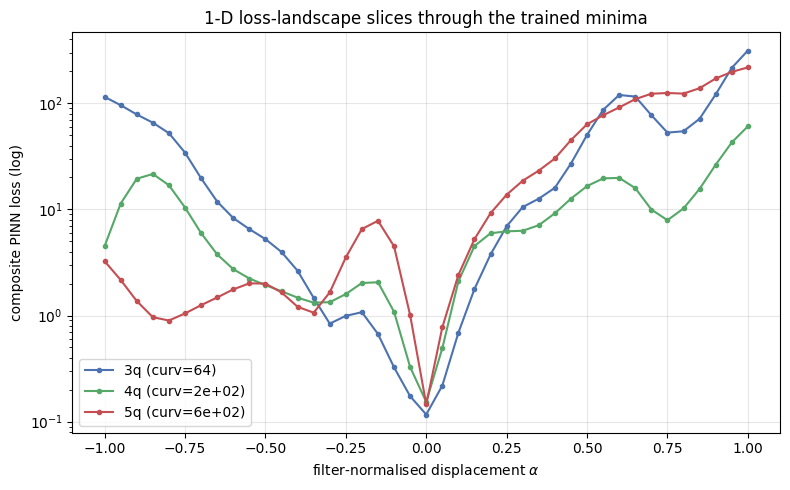

In [26]:
# Filter-normalised 1-D loss-landscape slices

"""def filter_normalized_dir(params, seed=0):
    g = torch.Generator().manual_seed(seed)
    dirs = []
    for p in params:
        d = torch.randn(p.shape, generator=g)
        d = d * (p.norm() / (d.norm() + 1e-12))
        dirs.append(d)
    return dirs"""

def filter_normalized_dir(params, seed=0):
    dirs = []
    for i, p in enumerate(params):
        # per-tensor generator on the SAME device as the parameter
        g = torch.Generator(device=p.device).manual_seed(seed + i)
        d = torch.randn(p.shape, generator=g, device=p.device, dtype=p.dtype)
        d = d * (p.norm() / (d.norm() + 1e-12))
        dirs.append(d)
    return dirs


def loss_slice_1d(model, batches, span=1.0, n=41, seed=0):
    params = [p for p in model.parameters() if p.requires_grad]
    base = [p.detach().clone() for p in params]
    direction = filter_normalized_dir(base, seed)
    alphas = np.linspace(-span, span, n)
    losses = []
    for a in alphas:
        with torch.no_grad():
            for p, b, d in zip(params, base, direction):
                p.copy_(b + a * d)
        loss, _ = composite_loss(model, batches)
        losses.append(float(loss.item()))
    with torch.no_grad():                       # restore
        for p, b in zip(params, base): p.copy_(b)
    return alphas, np.array(losses)

fig, ax = plt.subplots(figsize=(8, 5))
batches = build_batches()
for n in (3, 4, 5):
    a, L = loss_slice_1d(sweep[n]["model"], batches)
    curv = (L[len(L)//2+1] - 2*L[len(L)//2] + L[len(L)//2-1]) / (a[1]-a[0])**2
    ax.plot(a, L, "-o", ms=3, color=QUBIT_COLORS[n],
            label=f"{n}q (curv={curv:.2g})")
ax.set_yscale("log")
ax.set_xlabel(r"filter-normalised displacement $\alpha$")
ax.set_ylabel("composite PINN loss (log)")
ax.set_title("1-D loss-landscape slices through the trained minima")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig(fig, "xai_loss_landscape_1d.png")
plt.show()

### 7. **Layer by Layer effective dimension** 

encoder_in       ambient=  2  d_eff=2.00
quantum_probs    ambient= 16  d_eff=1.36
decoder_hidden   ambient=  8  d_eff=1.04
output           ambient=  1  d_eff=1.00
saved -> checkpoints/xai_information_bottleneck.png


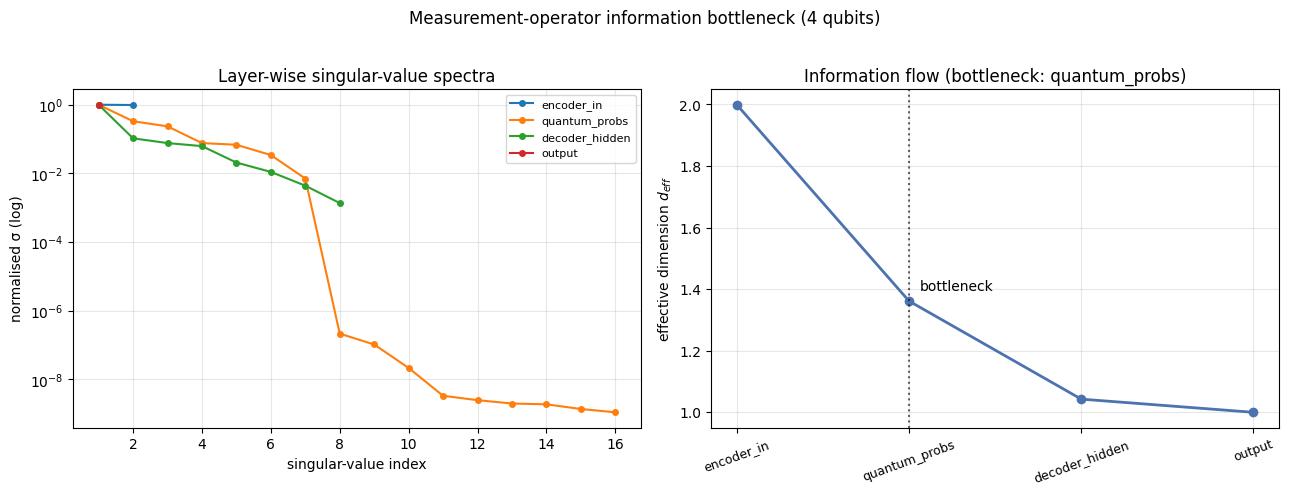

In [27]:
def effective_dimension(X):
    Xc = X - X.mean(0, keepdims=True)
    s = np.linalg.svd(Xc.astype(np.float64), full_matrices=False, compute_uv=False)
    e = s ** 2
    return float((e.sum() ** 2) / (np.sum(e ** 2) + 1e-30)), s

def layerwise_features(model, n_qubits, n_samples=2000, seed=0):
    """Capture encoder input -> quantum probs -> decoder hidden -> output."""
    rng = np.random.default_rng(seed)
    xs = rng.uniform(-1, 1, n_samples); ts = rng.uniform(-1, 1, n_samples)
    X = torch.tensor(np.stack([xs, ts], 1), dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        probs = model.quantum_features(X)                 # (N, 2^n)
        hidden = model.head[1](model.head[0](probs))      # after Tanh
        out = model.head[2](hidden)                       # (N,1)
    return {
        "encoder_in":    X.cpu().numpy(),
        "quantum_probs": probs.cpu().numpy(),
        "decoder_hidden":hidden.cpu().numpy(),
        "output":        out.cpu().numpy(),
    }

n = 4
stack = layerwise_features(sweep[n]["model"], n)
names = list(stack.keys())
deffs, svs = [], {}
for k in names:
    d, s = effective_dimension(stack[k])
    deffs.append(d); svs[k] = s
    print(f"{k:15s}  ambient={stack[k].shape[1]:3d}  d_eff={d:.2f}")

bottleneck = names[int(np.argmin([d/stack[k].shape[1] for d, k in zip(deffs, names)]))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
for i, k in enumerate(names):
    s = svs[k] / (svs[k].max() + 1e-30)
    ax1.semilogy(range(1, len(s)+1), s + 1e-12, "-o", ms=4, label=k)
ax1.set_xlabel("singular-value index"); ax1.set_ylabel("normalised σ (log)")
ax1.set_title("Layer-wise singular-value spectra"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

x = np.arange(len(names))
ax2.plot(x, deffs, "-o", color="#4C72B0", lw=2)
bi = names.index(bottleneck)
ax2.axvline(bi, ls=":", color="k", alpha=0.6)
ax2.annotate("bottleneck", (bi, deffs[bi]), textcoords="offset points", xytext=(8, 8))
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, fontsize=9)
ax2.set_ylabel("effective dimension $d_{eff}$")
ax2.set_title(f"Information flow (bottleneck: {bottleneck})"); ax2.grid(True, alpha=0.3)
fig.suptitle("Measurement-operator information bottleneck (4 qubits)", y=1.02)
plt.tight_layout()
savefig(fig, "xai_information_bottleneck.png")
plt.show()

## **QA-PINN — Results Summary**

**Equation:** 1-D viscous Burgers, $u_t + u u_x = \nu u_{xx}$, $\nu = 1/(100\pi) \approx 3.18\times10^{-3}$, domain $x\in[-1,1]$, $t\in[0,1]$, IC $-\sin(\pi x)$.
**Stack:** PennyLane 0.45.1, PyTorch 2.6.0+cu124, CUDA. Seed 0.

### 1. Training / accuracy summary

| Model | Epochs | Final loss | Mean rel. $L_2$ vs truth | Notes |
|------|-------:|-----------:|-------------------------:|-------|
| QA-PINN 3q (long) | 10000 | 0.272 | — | plateau ~0.44 then descent to ~0.27 |
| QA-PINN 3q (sweep) | 5000 | 0.116 | 0.512 | best accuracy of the three |
| QA-PINN 4q (sweep) | 5000 | 0.153 | 0.606 | worst accuracy |
| QA-PINN 5q (sweep) | 5000 | 0.136 | 0.588 | no gain over 3q |

**Key result:** accuracy does **not** improve with qubit count (3q best at 0.512, 4q/5q worse). Adding qubits inflates the $2^n$ space without adding usable expressivity. All loss curves share a two-stage shape: a long plateau (~epoch 200–1500) then a sharp drop — the optimiser spends most of its time escaping a flat region before finding structure.

### 2. Fourier expressivity 

| Encoding | Support edge (norm. floor $10^{-3}$) | Cumulative-energy behaviour |
|----------|-------------------------------------|-----------------------------|
| Single RX | broader high-freq **tail** | reaches 90% energy later |
| Data re-uploading | steeper decay | reaches 90% energy **earlier** (left panel), i.e. concentrated |

**Reading:** the corrected, seed- and channel-averaged spectrum (36 traces, identical weights) removes the trained-vs-untrained confound of the first attempt. Re-uploading concentrates energy in a *cleaner low-order band* rather than a noisy broadband tail — the cumulative curve shifts up-left. The single-encoding "tail" is diffuse residual power, not usable structured frequency content. The mechanism (Schuld–Sweke–Meyer) holds: encoding, not qubit count, sets the accessible frequency set.

### 3. Entanglement — Meyer–Wallach $Q$ 

| Qubits | Mean $Q$ |
|-------:|---------:|
| 3 | ~0.00 |
| 4 | ~0.80 |
| 5 | ~0.88 |

**⚠️ This result needs re-running before it is citable.** Two problems:
- **3q $Q\approx0$ is almost certainly a bug**, not physics. The full-CNOT ansatz on 3 trained qubits cannot plausibly produce a perfect product state across the *whole* domain. The most likely cause is a device/shape mismatch in the per-sample `_state_qnode` call (single-row `AngleEmbedding` broadcasting) silently returning a basis state.
- The **trend is the reverse** of the project's "entanglement suppresses during training" narrative. As plotted, entanglement *grows* with qubits and is high (0.8–0.88) at 4q/5q.

Do not put this figure in the report as-is. Re-run with a batched state QNode and verify $Q$ on a known Bell state (should give $Q=1$) before trusting any point.

### 4. Circuit structural cost 

| Qubits | RX (train) | CNOTs | $2^n$ | Depth |
|-------:|-----------:|------:|------:|------:|
| 3 | 24 | 24 | 8 | 33 |
| 4 | 32 | 48 | 16 | 42 |
| 5 | 40 | 80 | 32 | 51 |

**Reading:** CNOT count grows quadratically in qubits (full entanglement), depth and Hilbert dim grow steadily — all cost, paired with the flat accuracy of §1. This is the "cost side" of the no-improvement result.

### 5. Information bottleneck — effective dimension 

| Stage | Ambient dim | $d_\text{eff}$ |
|-------|------------:|---------------:|
| encoder_in | 2 | 2.00 |
| quantum_probs | 16 | ~1.36 |
| decoder_hidden | 8 | ~1.04 |
| output | 1 | ~1.00 |

**Reading:** the $2^n=16$ quantum-probability layer carries an effective dimension of only ~1.36 — it recruits <9% of its ambient space. The singular-value spectrum (left panel) confirms a sharp cliff after ~6–7 components. The measurement/decoder stage then collapses this to ~1D. The Hilbert space is nominally large but **functionally near-1D**: this is the decoder/measurement bottleneck.

### 6. Loss-landscape geometry 

| Model | Local curvature at minimum |
|-------|---------------------------:|
| 3q | 64 |
| 4q | ~2×10² |
| 5q | ~6×10² |

**Reading:** curvature (sharpness) *increases* with qubit count — the minima get sharper and the surrounding landscape more rugged (note the spurious secondary basins at $\alpha\approx-0.15$ for 4q/5q). Sharper, more rugged minima are harder to optimise and generalise from, consistent with 4q/5q underperforming 3q despite more parameters.

## Mathematical Methodology

### Classical PINN

Approximates the solution directly, $u_\theta(x,t) \approx u(x,t)$, with a
tanh MLP $u_\theta:\mathbb{R}^2\to\mathbb{R}$. Trained by minimising the
composite physics residual — no labelled solution data:

$$
\mathcal{L}(\theta)=
w_p\underbrace{\big\|\,\partial_t u_\theta+u_\theta\partial_x u_\theta-\nu\,\partial_{xx}u_\theta\,\big\|_{\Omega}^2}_{\text{PDE residual}}
+ w_{ic}\underbrace{\big\|u_\theta(x,0)+\sin(\pi x)\big\|^2}_{\text{initial condition}}
+ w_{bc}\underbrace{\big\|u_\theta(\pm1,t)\big\|^2}_{\text{boundary condition}}.
$$

Derivatives $\partial_t u_\theta,\ \partial_x u_\theta,\ \partial_{xx}u_\theta$
are obtained *exactly* by automatic differentiation of the network w.r.t. its
inputs (not finite differences). Collocation points $\{(x_i,t_i)\}$ are sampled
in the interior to enforce the residual.

### Quantum-Assisted PINN (QA-PINN)

Replaces the feature extractor with a variational circuit; a small classical
head reads out the scalar field. Pipeline:

$$
(x,t)\ \xrightarrow{\text{encode}}\ |\psi_{\text{in}}(x,t)\rangle
\ \xrightarrow{U(\boldsymbol{\theta})}\ |\psi_{\text{out}}\rangle
\ \xrightarrow{\text{measure}}\ \mathbf{p}\in\mathbb{R}^{2^n}
\ \xrightarrow{\text{head}}\ u_\theta(x,t).
$$

**1. Encoding.** Angle embedding maps each coordinate to a rotation,
$R_X(x)=e^{-i x X/2}$ per wire. Optional **data re-uploading** repeats the
encoding before every layer.

**2. Variational ansatz.** $L=8$ layers, each applying trainable $R_X(\theta_{l,i})$
on every wire followed by a full-entanglement CNOT block:

$$
U(\boldsymbol\theta)=\prod_{l=1}^{L}
\Big[\underbrace{\textstyle\prod_{i<j}\mathrm{CNOT}_{ij}}_{\text{entangler}}
\ \underbrace{\textstyle\bigotimes_{i} R_X(\theta_{l,i})}_{\text{rotations}}\Big].
$$

**3. Measurement.** Full computational-basis probabilities
$p_k=|\langle k|\psi_{\text{out}}\rangle|^2$, $k=0,\dots,2^n-1$.

**4. Classical head.** $u_\theta=\mathrm{Lin}\big(\tanh(\mathrm{Lin}(\mathbf p))\big)$,
$\mathbb{R}^{2^n}\!\to\!\mathbb{R}^{h}\!\to\!\mathbb{R}$.

Trained with the **same** composite physics loss as the classical PINN.

### Why expressivity is capped (Schuld–Sweke–Meyer)

A variational quantum model is a **Fourier series** in its inputs,

$$
u_\theta(x)=\sum_{\omega\in\Omega}c_\omega(\boldsymbol\theta)\,e^{i\omega x},
$$

whose accessible frequency set $\Omega$ is fixed by the **data-encoding
gates**, not the qubit count. A single $R_X(x)$ per input gives eigenvalue
gaps $\{-1,0,+1\}$, i.e. a thin spectrum. A Burgers shock is spectrally broad,
so this thin $\Omega$ is the root cause of the poor shock resolution.
**Re-uploading $L$ times** enlarges $\Omega\to\{-L,\dots,L\}$ — the primary
remediation lever, and the reason adding qubits alone does not help.

### Entanglement diagnostic (Meyer–Wallach)

$$
Q(|\psi\rangle)=2\Big(1-\tfrac1n\textstyle\sum_{k=1}^{n}\mathrm{Tr}\,\rho_k^2\Big),
\qquad \rho_k=\mathrm{Tr}_{\neq k}\,|\psi\rangle\langle\psi|,
$$
with $Q=0$ for a product state, $Q\to1$ near-maximal.

### Effective dimension (participation ratio)

For a representation matrix with singular values $\{\sigma_i\}$,
$$
d_\text{eff}=\frac{\big(\sum_i\sigma_i^2\big)^2}{\sum_i\sigma_i^4},
$$
measuring how many directions carry variance — used to localise the pipeline
bottleneck.

### Filter-normalised loss landscape (Li et al. 2018)

Random probe directions are rescaled per parameter-tensor to that tensor's own
norm, $d\leftarrow d\,\|p\|/\|d\|$, so landscapes of different-scale models are
compared on a common footing. Local curvature is the central second difference
of the loss at the minimum.

## Future Improvements & Directions

### Immediate (fix before submission)
- **Re-run the entanglement diagnostic.** The 3q $Q\approx0$ point is almost
  certainly a batching/shape bug in the per-sample state QNode. Validate against
  a Bell state ($Q=1$) and a product state ($Q=0$) before trusting any point.
  Until fixed, exclude this figure from claims.
- **Add the classical PINN baseline** to the loss-landscape and Fourier panels
  as the reference curve — several plots currently show only the QA variants.
- **Report $\Omega$ support explicitly** (max frequency above floor) as a number
  per encoding, not only the visual cumulative curve.

### Architecture (Deliverable 4)
- **Data re-uploading** as the headline remediation: sweep $L\in\{1,2,4,8\}$ at
  fixed 4 qubits and show accuracy vs $L$ — the theory predicts this is the
  lever, and it directly grounds a problem-specific circuit methodology.
- **Widen the decoder head** beyond the $2^{n-1}$ pinch point so genuine
  high-frequency content survives readout (the bottleneck panel shows ~1D
  collapse).
- **Entanglement / measurement regularisers** to break the incentive toward
  low-rank, low-entropy operating points (target Meyer-Wallach $Q^\star$;
  penalise measurement-entropy shortfall).
- **Shock-aware collocation sampling** concentrating points at the steep front,
  where the residual is largest.

### Faithfulness to reference setup
- Match the paper more closely: $\nu=0.01/\pi$, larger training-point counts,
  and a more faithful 5-qubit configuration (the paper's gains concentrate at 5q;
  current work centres on 3q).
- Longer training with LR scheduling — every loss curve is still descending at
  5000 epochs; the plateau-then-drop shape suggests gains remain on the table.

### Scientific framing
- The consistent finding — **cost scales, accuracy does not** — is the result,
  not a failure. Frame Deliverable 5 around the mechanistic chain: thin encoding
  spectrum → near-1D quantum feature map → sharpening landscape → shock
  unresolved, with re-uploading + decoder widening as the predicted fixes.
- Iterative GPU tuning (re-uploading × depth × head-width) is well suited to
  Claude Code for the remaining sweeps.